<font size = 10>Temperature Gradient Descent</font>

# Local run setup: Windows vs Mac (CUDA vs MPS)

Set the parameter below to match your machine:

- **Windows** → prefers **CUDA** (NVIDIA GPU) if available  
- **Mac** → prefers **MPS** (Apple Silicon GPU) if available  

If the preferred accelerator is not available, the notebook will **fall back to CPU**.

This notebook also includes plotting cells, so the helper `to_numpy(...)` safely moves tensors to CPU for Matplotlib when needed.


In [1]:
# ===== Platform / device selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import matplotlib.pyplot as plt

def pick_device(platform_choice: str) -> torch.device:
    p = platform_choice.strip().lower()

    if p.startswith("mac"):
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    if p.startswith("win"):
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    raise ValueError('PLATFORM must be "Windows" or "Mac".')

DEVICE = pick_device(PLATFORM)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().item()
    return float(x)

print(f"PLATFORM = {PLATFORM}")
print(f"Selected DEVICE = {DEVICE}")

if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA devices available: {torch.cuda.device_count()}")
elif DEVICE.type == "mps":
    print("MPS backend is available (Apple Silicon GPU).")
else:
    print("Running on CPU.")


PLATFORM = Mac
Selected DEVICE = mps
MPS backend is available (Apple Silicon GPU).


# Define inputs and outputs for the model


In [2]:
t_c = torch.tensor(
    [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0],
    device=DEVICE
)
t_u = torch.tensor(
    [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4],
    device=DEVICE
)


# Visualize the data

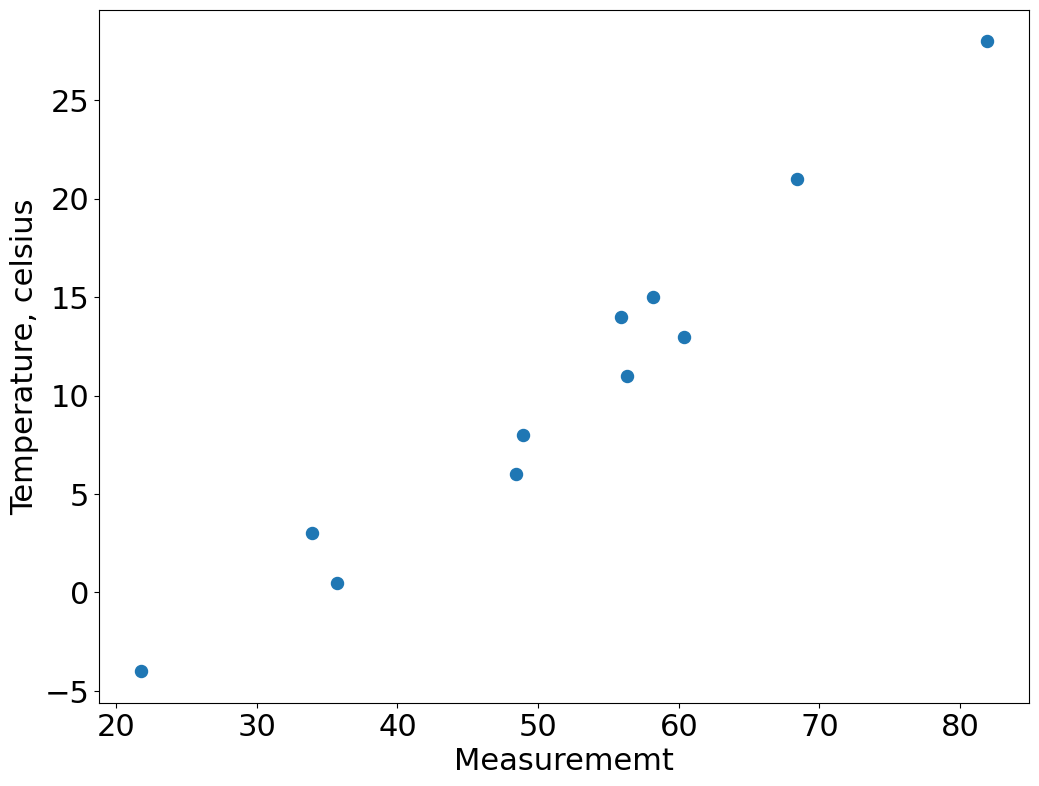

In [3]:
plt.figure(figsize=(12,9))
plt.scatter(to_numpy(t_u), to_numpy(t_c), s=75)
plt.xlabel('Measurememt', fontsize=22)
plt.ylabel('Temperature, celsius', fontsize=22)
plt.gca().tick_params(axis='x', labelsize=22)
plt.gca().tick_params(axis='y', labelsize=22)


## Model Specification

It appears that there is a linear relationship between the `measurement` and the true value of the `temperature`.

### Model

$\large t_c = \mathbf{w} \cdot t_u + \mathbf{b}$

**Model parameters**

- $w$: *weight*
- $b$: *bias*

<p style="font-size:30px">Loss Function:</p>
<p style="text-align:center">$\large L=(t_p - t_c)^{2}$</p>
<p style="text-align:center">$\large L(t_u, t_c)_{w,b}=( [w \cdot t_u + b] - t_c)^{2}$</p>

<p>Objective: find $w$ and $b$ that minimize $L$ for all values $t_u$ and $t_c$</p>

<p style="font-size:20px">Change of the Loss Function wrt parameters $w$ and $b$ for the pair of values $t_u$ and $t_c$ :</p>

## Change of the Loss Function wrt parameters $w$ and $b$ for the pair of values $t_u$ and $t_c$:

$$\large dL_{w}(t_u, t_c)=\frac {1}{2\Delta}\cdot [L(t_u, t_c)_{w+\Delta,b}-L(t_u, t_c)_{w-\Delta,b}]$$

$$\large dL_{w}(t_u, t_c)=\frac {1}{2\Delta}\cdot [( [(w+\Delta) \cdot t_u + b] - t_c)^{2}-( [(w-\Delta) \cdot t_u + b] - t_c)^{2}]$$

$$\large dL_{b}(t_u, t_c)=\frac {1}{2\Delta}\cdot [L(t_u, t_c)_{w,b+\Delta}-L(t_u, t_c)_{w,b-\Delta}]$$

$$\large dL_{b}(t_u, t_c)=\frac {1}{2\Delta}\cdot [( [w \cdot t_u + (b+\Delta)] - t_c)^{2}-( [w \cdot t_u + (b-\Delta)] - t_c)^{2}]$$



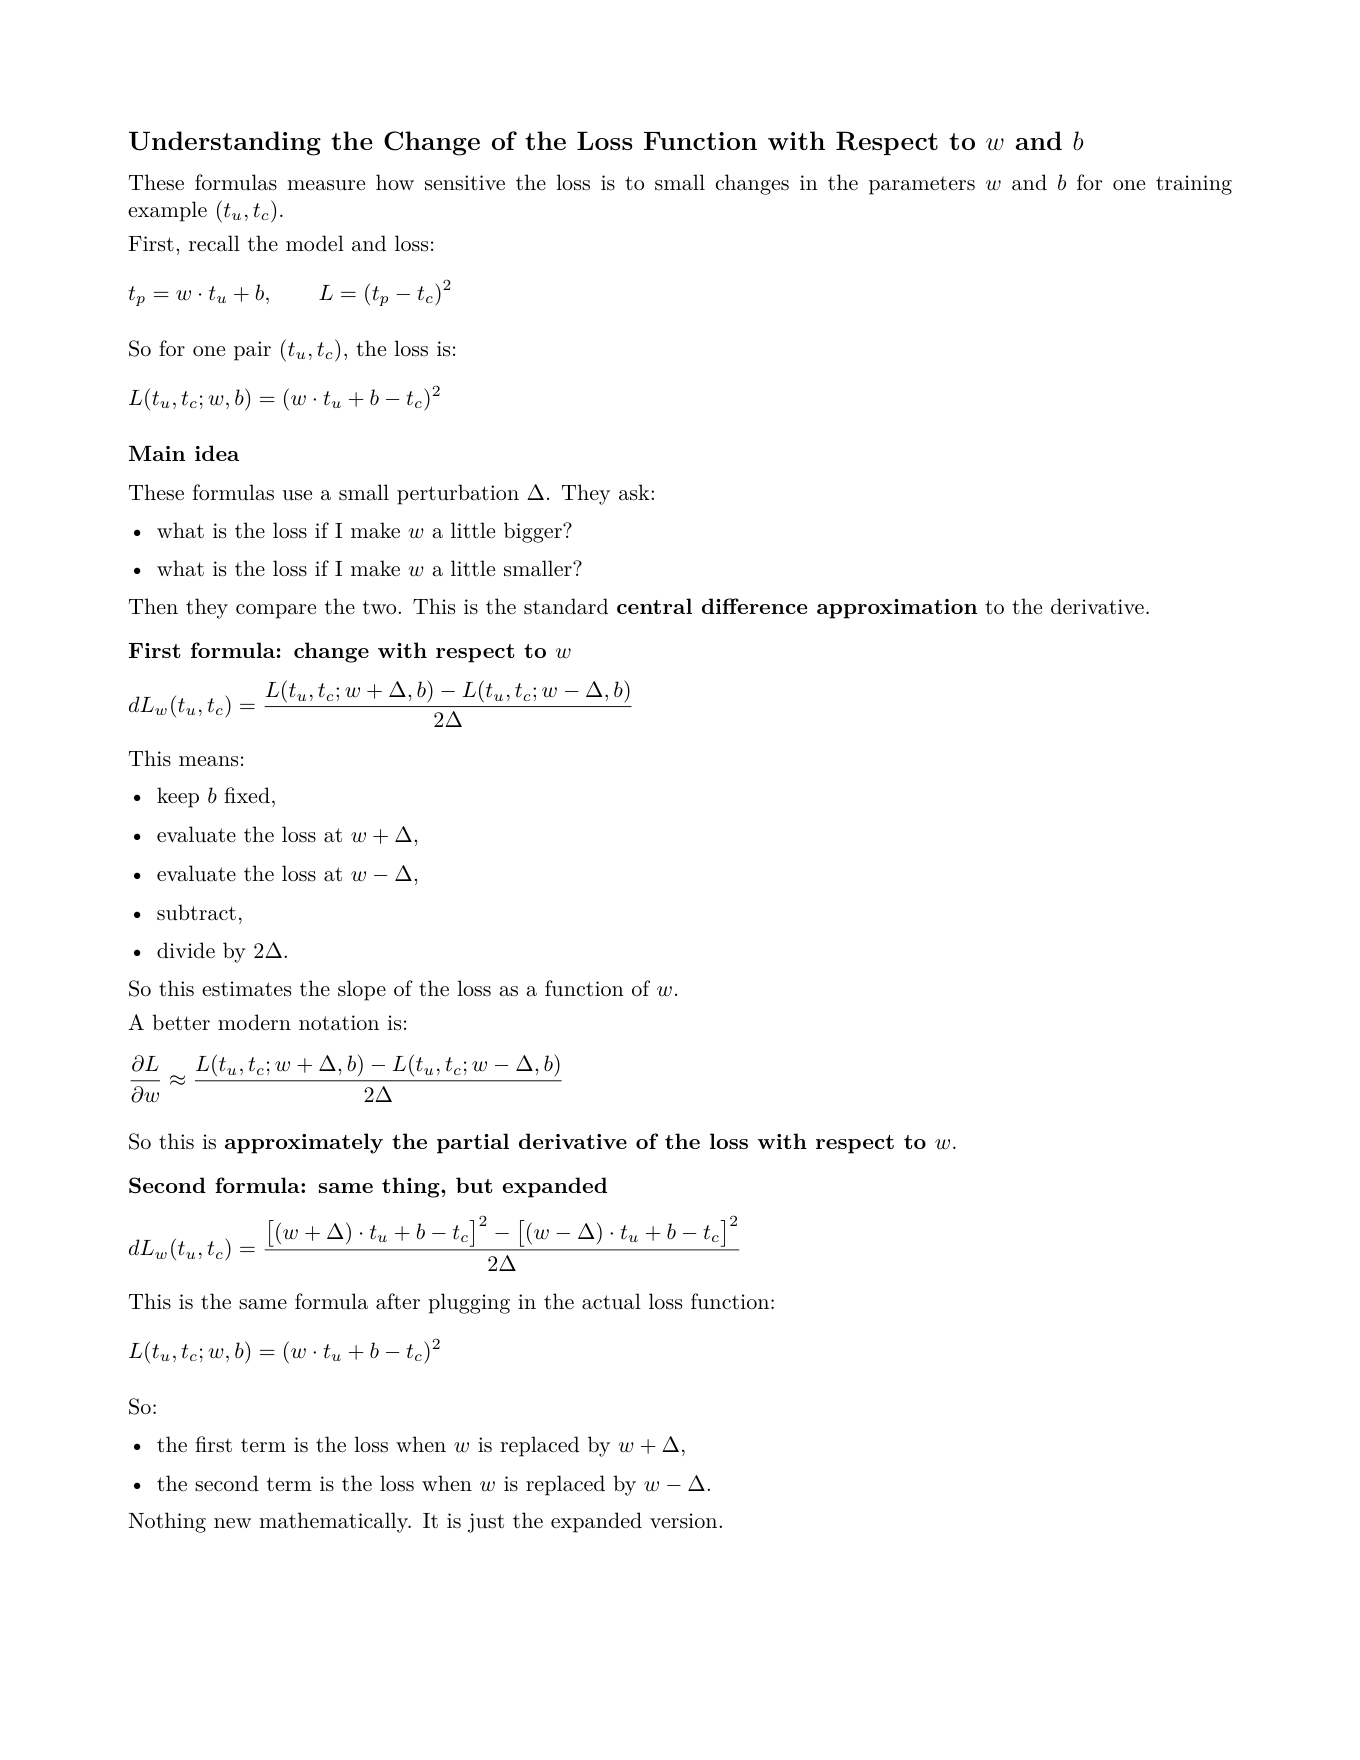
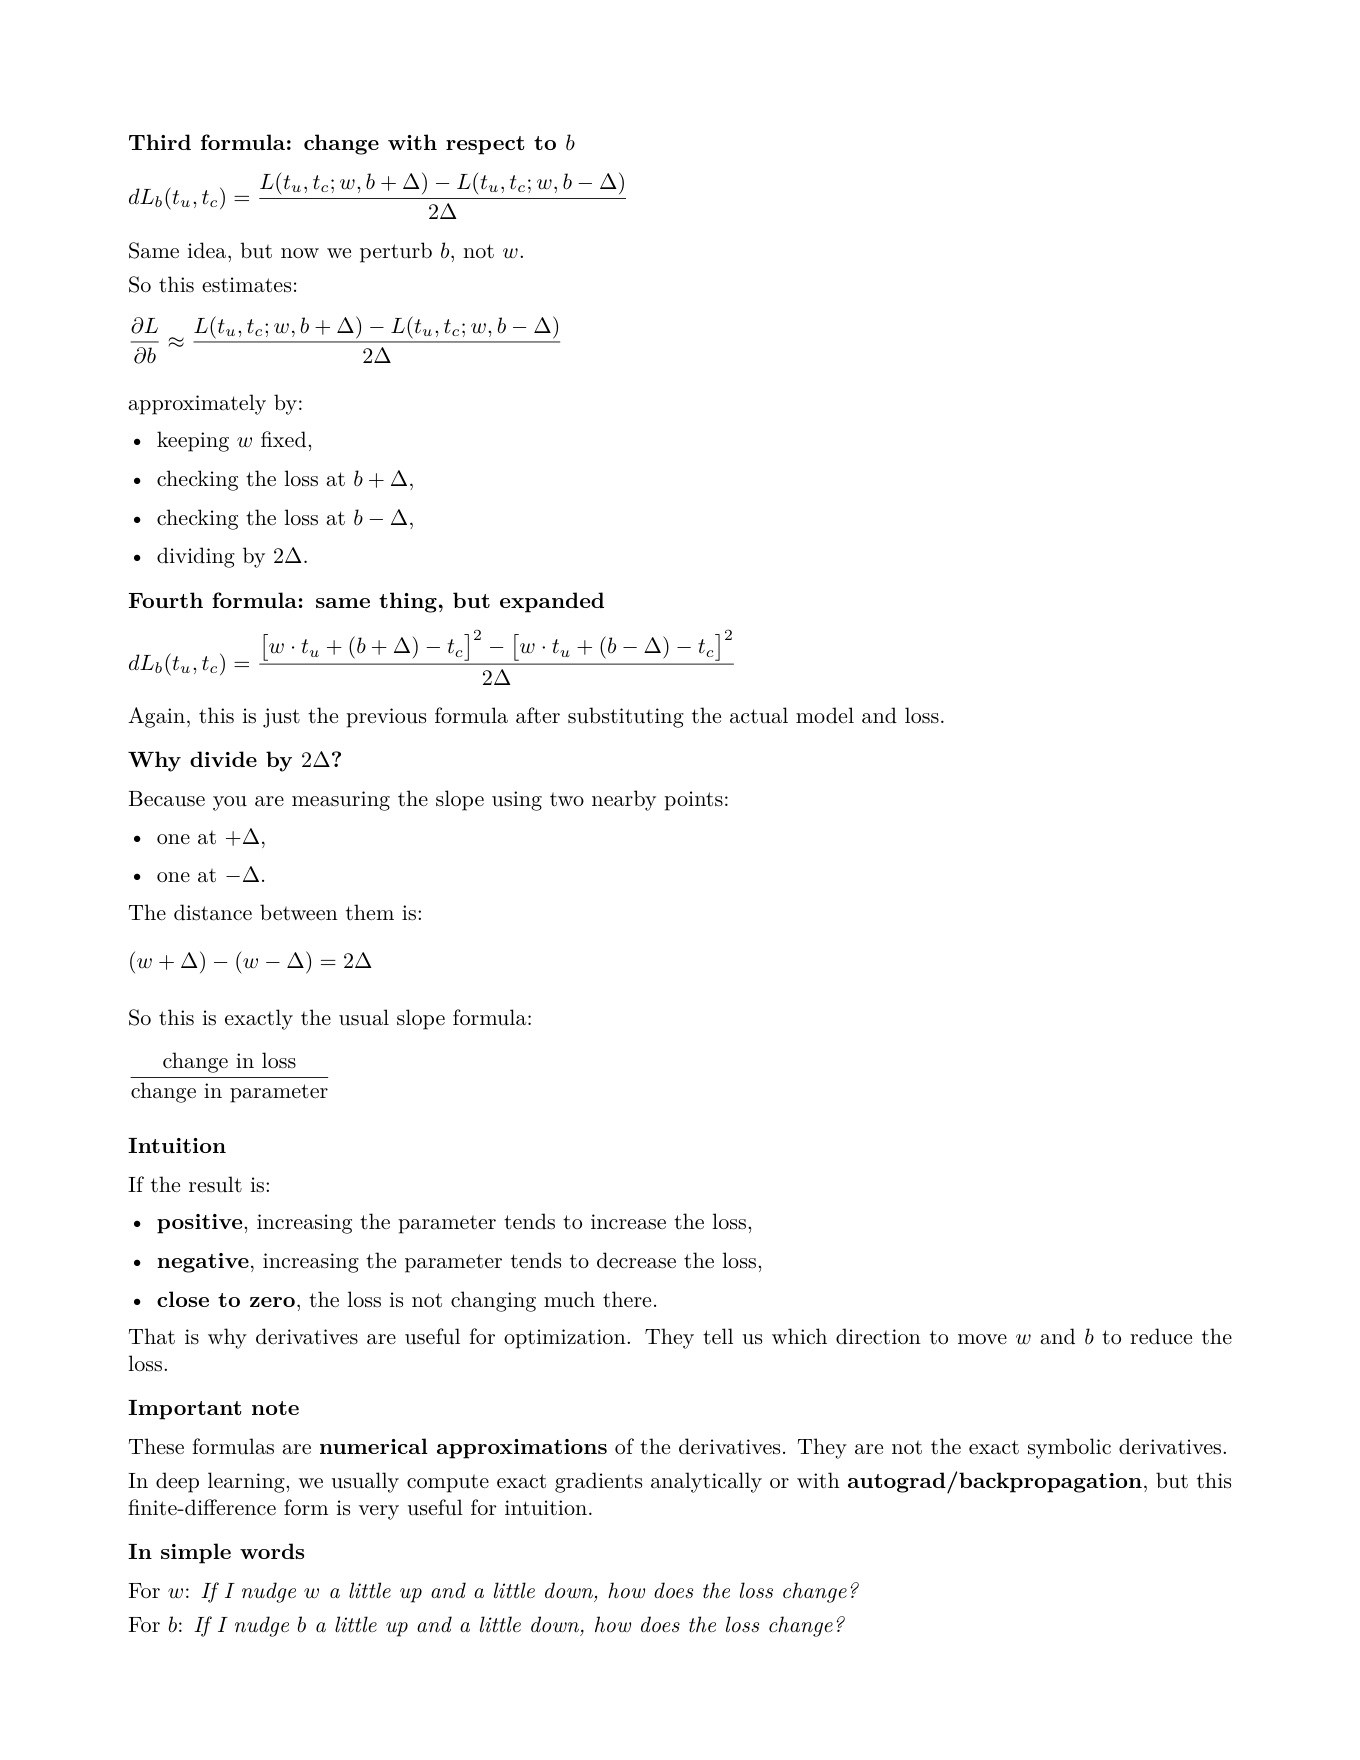

In [15]:
# If needed once, uncomment:
# %pip install pymupdf

from pathlib import Path
import base64
from IPython.display import HTML, display
import fitz  # PyMuPDF

pdf_path = Path("GD.pdf")

if not pdf_path.exists():
    raise FileNotFoundError(f"Could not find: {pdf_path.resolve()}")

dpi = 160                 # increase for sharper pages
viewer_height = "900px"   # height of the scrollable viewer
page_gap_px = 18          # space between pages
page_width_percent = 95   # width of each page inside the viewer

doc = fitz.open(pdf_path)

pages_html = []
for page_num in range(doc.page_count):
    page = doc.load_page(page_num)
    pix = page.get_pixmap(dpi=dpi, alpha=False)
    png_b64 = base64.b64encode(pix.tobytes("png")).decode("utf-8")

    pages_html.append(f"""
        <div style="margin-bottom:{page_gap_px}px; text-align:center;">
            <div style="font-family:Arial, sans-serif; font-size:14px; color:#444; margin-bottom:6px;">
                Page {page_num + 1}
            </div>
            <img
                src="data:image/png;base64,{png_b64}"
                style="width:{page_width_percent}%; max-width:1200px; border:1px solid #ccc; box-shadow:0 1px 4px rgba(0,0,0,0.08);"
            >
        </div>
    """)

doc.close()

html = f"""
<div style="
    height:{viewer_height};
    overflow-y:auto;
    overflow-x:hidden;
    border:1px solid #ccc;
    padding:12px;
    background:white;
">
    {''.join(pages_html)}
</div>
"""

display(HTML(html))

In [10]:
def model(t_u, w, b): 
    return w* t_u + b
def loss_fnc(t_u, t_c, w, b):
    return torch.mean(( model(t_u, w,b) -t_c)**2)

## Use gradient descent technique to:
- start with initial values of $w$ and $b$
- repeat 
    - compute gradients $dL_{w}(t_u, t_c)$ and $dL_{b}(t_u, t_c)$
    - adjust $w$ and $b$: 
        - $w \Rightarrow w-lr \cdot dL_{w}(t_u, t_c)$ 
        - $b \Rightarrow b-lr \cdot dL_{b}(t_u, t_c)$

In [5]:
w = torch.tensor(1.0, device=DEVICE)
b = torch.tensor(0.0, device=DEVICE)

# define gradient descent parameters
delta = 0.001
lr = 0.0003
number_of_iterations = 100000
loss_over_t = torch.zeros(number_of_iterations, dtype=torch.float, device=DEVICE)

for i in range(number_of_iterations):
    loss_over_t[i] = loss_fnc(t_u, t_c, w, b)  # compute loss to monitor progress.
    # compute gradients
    dlw = (loss_fnc(t_u, t_c, w + delta, b) - loss_fnc(t_u, t_c, w - delta, b)) / (2 * delta)
    dlb = (loss_fnc(t_u, t_c, w, b + delta) - loss_fnc(t_u, t_c, w, b - delta)) / (2 * delta)
    # update parameter values
    w = w - lr * dlw
    b = b - lr * dlb


In [6]:
print(f"Results: w={to_scalar(w):0.3f}, b={to_scalar(b):0.3f}")
print(f"Final loss: {to_scalar(loss_over_t[-1]):0.6f}")
print(f"Mean error: {to_scalar((model(t_u, w, b) - t_c).mean().abs()):0.6f}")


Results: w=0.535, b=-17.215
Final loss: 2.928353
Mean error: 0.007906


## Explore the model

### Display convergence

Text(0.5, 0, 'iteration')

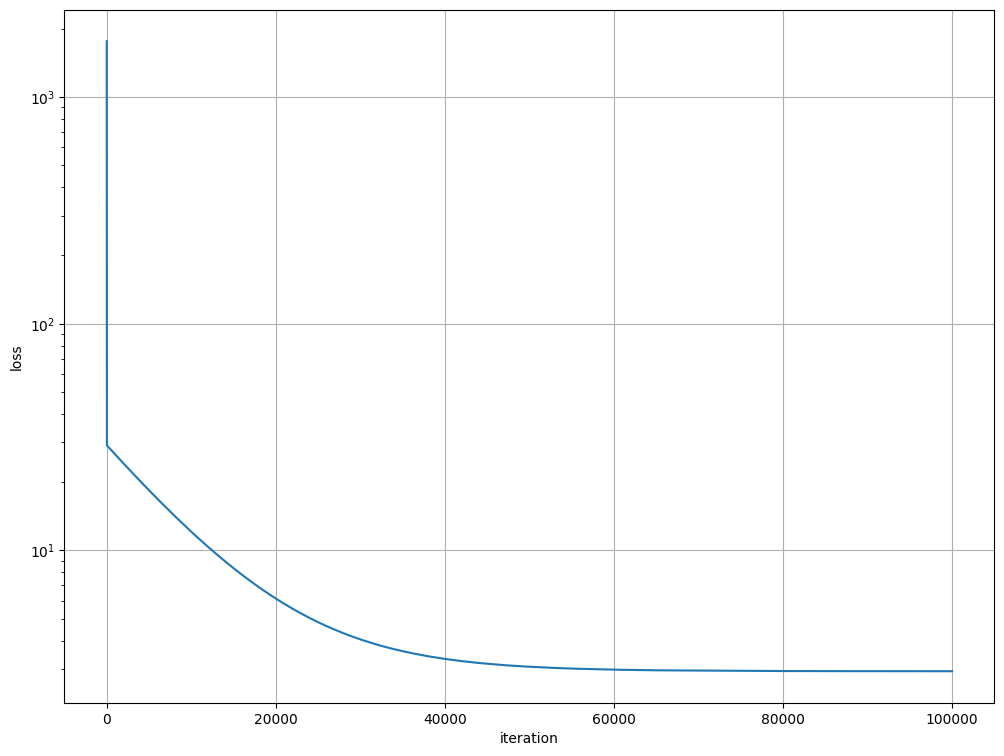

In [7]:
fig, ax = plt.subplots(figsize=(12,9))
ax.semilogy(range(len(loss_over_t)), to_numpy(loss_over_t))

plt.grid()
ax.set_ylabel('loss')
ax.set_xlabel('iteration')


### Demonstrate the rate of change of the loss function
plot $Loss_{t+1}-Loss_{t}$ over time

Text(0.5, 0, 'iteration')

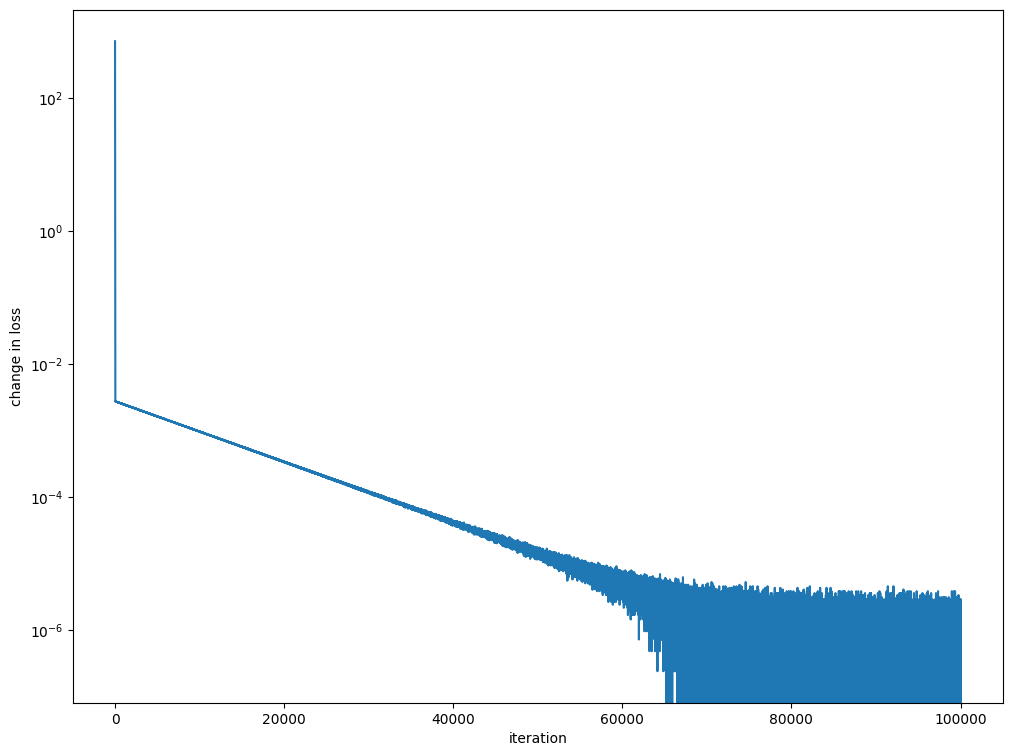

In [8]:
fig, ax = plt.subplots(figsize=(12,9))
ax.semilogy(
    range(len(loss_over_t) - 1),
    to_numpy(torch.abs(loss_over_t[1:] - loss_over_t[:-1]))
)
ax.set_ylabel('change in loss')
ax.set_xlabel('iteration')


### Demonstrate prediction

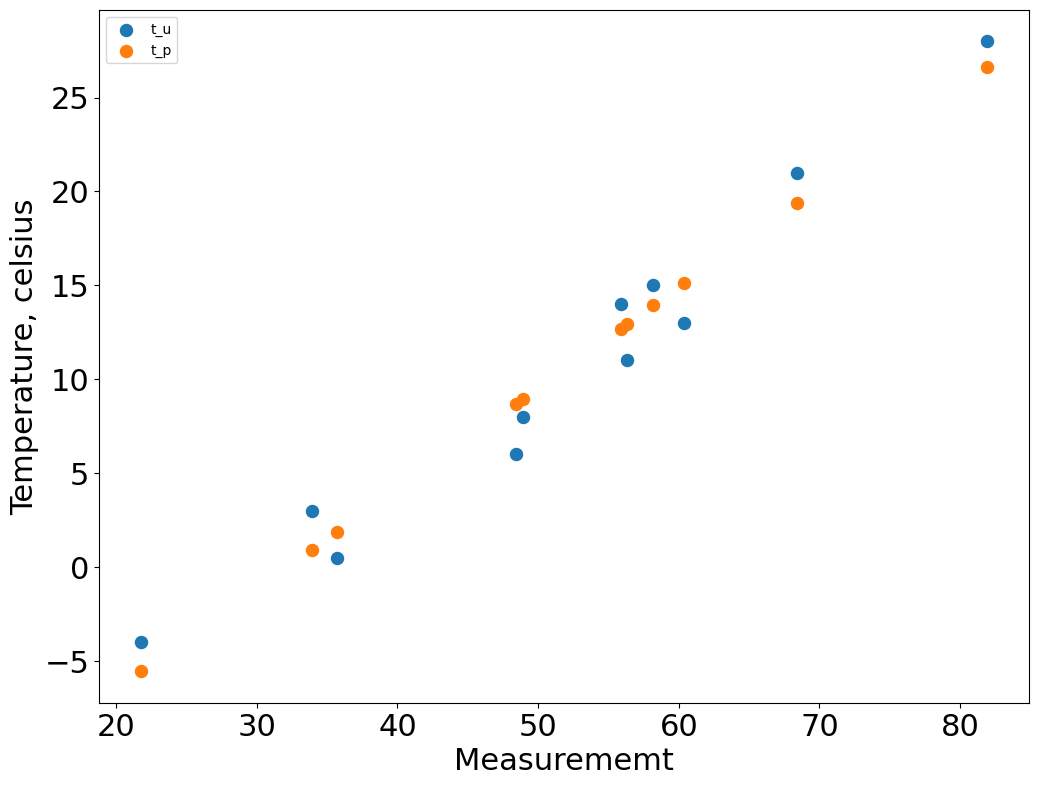

In [9]:
plt.figure(figsize=(12,9))
plt.scatter(to_numpy(t_u), to_numpy(t_c), s=75, label='t_u')
plt.scatter(to_numpy(t_u), to_numpy(model(t_u, w, b)), s=75, label='t_p')
plt.xlabel('Measurememt', fontsize=22)
plt.ylabel('Temperature, celsius', fontsize=22)
plt.gca().tick_params(axis='x', labelsize=22)
plt.gca().tick_params(axis='y', labelsize=22)
plt.legend()


# degrees of freedom: 
- which parameters should we change each iteration? $w$, $b$ or both? 
- how should we change the learning rate $lr$? Should there be $lr_w$ and $lr_b$?
- what is the termination condition? Number of iterations? Time?  Loss objective? Conversion of Loss? 
- Loss computation: 
    - Update parameters for every single (random) sample (online)? 
    - Update parameters after testing all  samples (large batch) ?
    - Split data into mini-batches? 